**Task** **1** : **Credit** **Score** **Model**

In [ ]:
# Task 1: Credit Score Model



In [ ]:
# Import Library

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay
)

import joblib

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load Dataset
!wget -O cs-training-selected-columns.csv https://raw.githubusercontent.com/sunshineluyao/GiveMeSomeCredit/master/cs-training.csv
df = pd.read_csv("cs-training-selected-columns.csv")

print("Dataset loaded successfully!")

--2026-08-12 13:40:35--  https://raw.githubusercontent.com/sunshineluyao/GiveMeSomeCredit/master/cs-training.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7564965 (7.2M) [text/plain]
Saving to: ‘cs-training-selected-columns.csv’

cs-training-selecte 100%[===================>]   7.21M  --.-KB/s    in 0.09s   

2026-08-12 13:40:35 (77.8 MB/s) - ‘cs-training-selected-columns.csv’ saved [7564965/7564965]

Dataset loaded successfully!


In [ ]:
print("Shape:", df.shape)

display(df.head())

Shape: (150000, 12)


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [ ]:
df.info()

print("\nColumn names:")
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [ ]:
if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)

print(df.columns)

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')


In [ ]:
# Rename The Columns

df.rename(columns={
    'SeriousDlqin2yrs': 'Default',
    'RevolvingUtilizationOfUnsecuredLines': 'Credit_Utilization',
    'age': 'Age',
    'NumberOfTime30-59DaysPastDueNotWorse': 'Late_30_59_Days',
    'DebtRatio': 'Debt_Ratio',
    'MonthlyIncome': 'Monthly_Income',
    'NumberOfOpenCreditLinesAndLoans': 'Open_Credit_Lines',
    'NumberOfTimes90DaysLate': 'Late_90_Days',
    'NumberRealEstateLoansOrLines': 'Real_Estate_Loans',
    'NumberOfTime60-89DaysPastDueNotWorse': 'Late_60_89_Days',
    'NumberOfDependents': 'Dependents'
}, inplace=True)

display(df.head())

,Default,Credit_Utilization,Age,Late_30_59_Days,Debt_Ratio,Monthly_Income,Open_Credit_Lines,Late_90_Days,Real_Estate_Loans,Late_60_89_Days,Dependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [ ]:
print(df['Default'].value_counts())

print(
    df['Default']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Default
0    139974
1     10026
Name: count, dtype: int64
Default
0    93.32
1     6.68
Name: proportion, dtype: float64


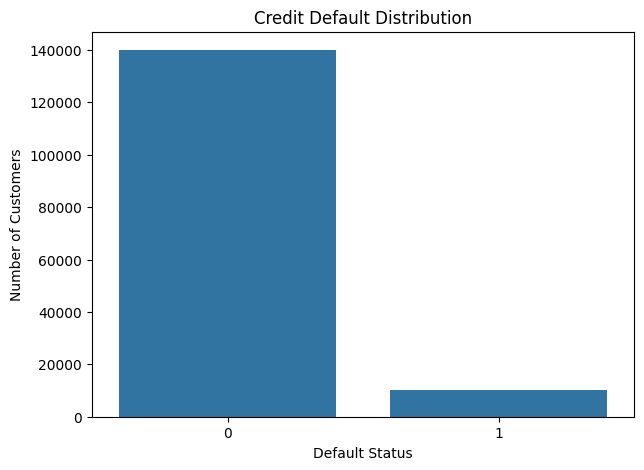

In [ ]:
# Visulize

plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x='Default'
)

plt.title("Credit Default Distribution")
plt.xlabel("Default Status")
plt.ylabel("Number of Customers")

plt.show()

In [ ]:
# missing values Analysis

missing = df.isnull().sum()

missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing_Values': missing.values
})

missing_df = missing_df[
    missing_df['Missing_Values'] > 0
]

display(missing_df)

,Column,Missing_Values
5,Monthly_Income,29731
10,Dependents,3924


In [ ]:
# Percentage
missing_percentage = (
    df.isnull().mean() * 100
).sort_values(ascending=False)

display(
    missing_percentage[
        missing_percentage > 0
    ]
)

,0
Monthly_Income,19.820667
Dependents,2.616000


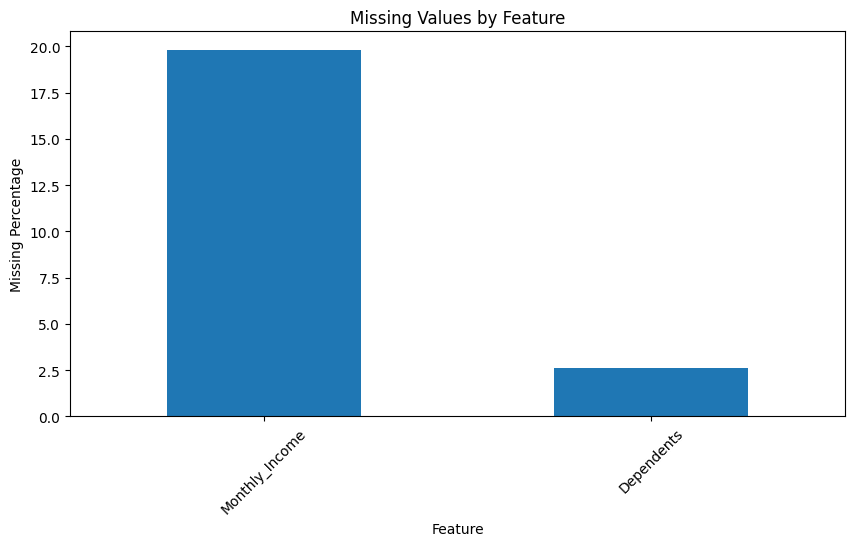

In [ ]:
# Visulize Missing Values

plt.figure(figsize=(10,5))

missing_percentage[
    missing_percentage > 0
].plot(
    kind='bar'
)

plt.title("Missing Values by Feature")
plt.xlabel("Feature")
plt.ylabel("Missing Percentage")

plt.xticks(rotation=45)

plt.show()

In [ ]:
# Statistical
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Default,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
Credit_Utilization,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
Age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
Late_30_59_Days,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
Debt_Ratio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
Monthly_Income,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
Open_Credit_Lines,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
Late_90_Days,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
Real_Estate_Loans,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
Late_60_89_Days,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


In [ ]:
# check duplicate values

print(
    "Duplicate rows:",
    df.duplicated().sum()
)

# remove duplicate

df = df.drop_duplicates()

print(
    "Shape after removing duplicates:",
    df.shape
)

Duplicate rows: 609
Shape after removing duplicates: (149391, 11)


In [ ]:
# check invalid age

print(
    df[df['Age'] <= 0]
)

df.loc[
    df['Age'] <= 0,
    'Age'
] = np.nan

       Default  Credit_Utilization  Age  Late_30_59_Days  Debt_Ratio  \
65695        0                 1.0    0                1    0.436927   

       Monthly_Income  Open_Credit_Lines  Late_90_Days  Real_Estate_Loans  \
65695          6000.0                  6             0                  2   

       Late_60_89_Days  Dependents  
65695                0         2.0  


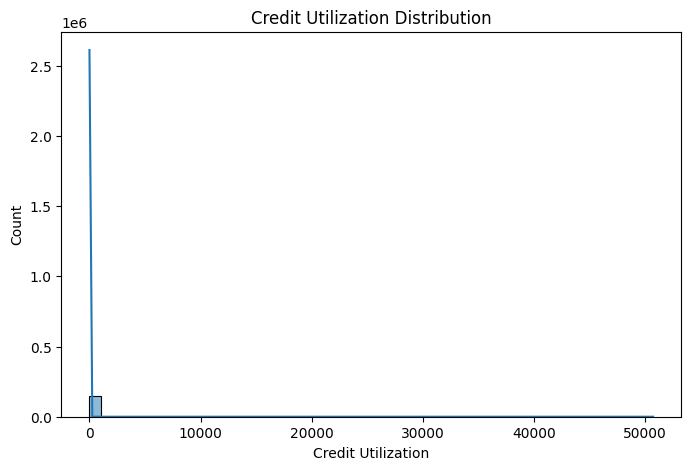

In [ ]:
# credit utilization analysis

plt.figure(figsize=(8,5))

sns.histplot(
    df['Credit_Utilization'],
    bins=50,
    kde=True
)

plt.title(
    "Credit Utilization Distribution"
)

plt.xlabel(
    "Credit Utilization"
)

plt.show()

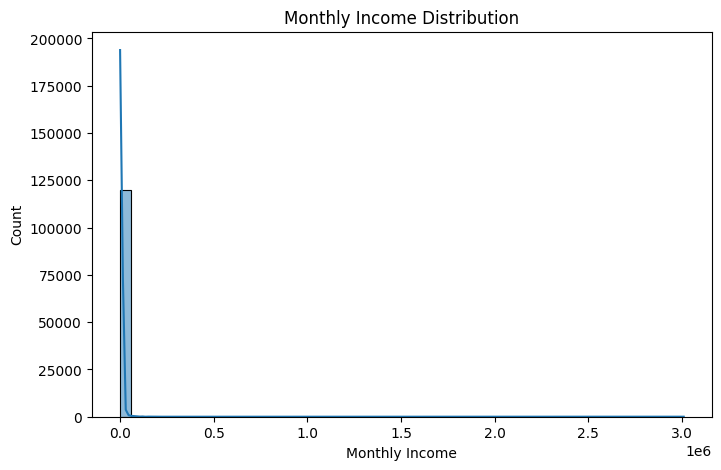

In [ ]:
# income Distrubution

plt.figure(figsize=(8,5))

sns.histplot(
    df['Monthly_Income'].dropna(),
    bins=50,
    kde=True
)

plt.title(
    "Monthly Income Distribution"
)

plt.xlabel(
    "Monthly Income"
)

plt.show()

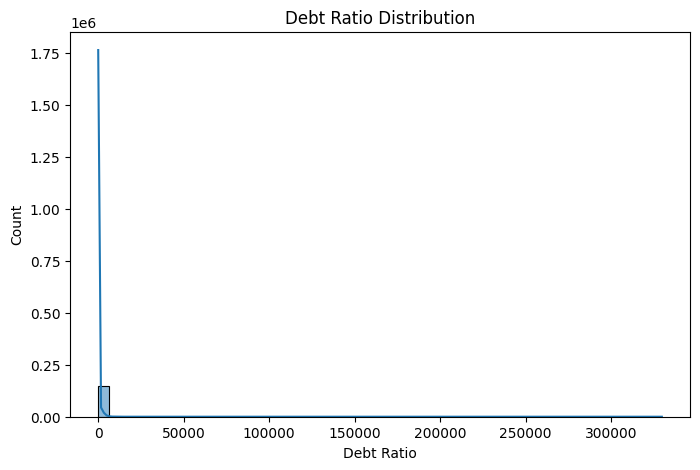

In [ ]:
# debt ratio distrubution

plt.figure(figsize=(8,5))

sns.histplot(
    df['Debt_Ratio'],
    bins=50,
    kde=True
)

plt.title(
    "Debt Ratio Distribution"
)

plt.xlabel(
    "Debt Ratio"
)

plt.show()

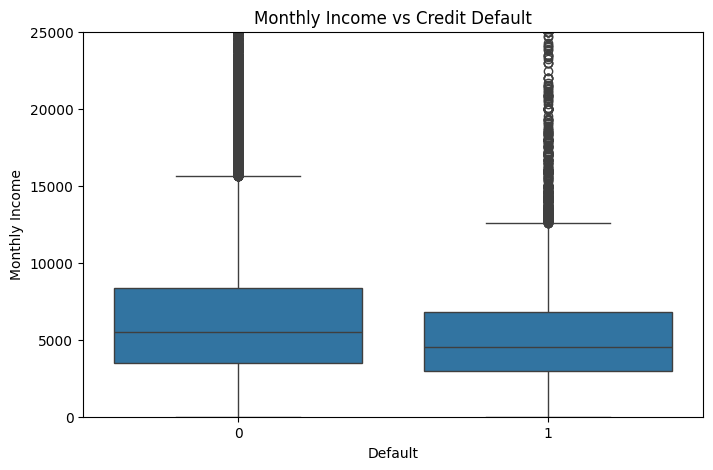

In [ ]:
# income vs default

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Default',
    y='Monthly_Income'
)

plt.title(
    "Monthly Income vs Credit Default"
)

plt.xlabel(
    "Default"
)

plt.ylabel(
    "Monthly Income"
)

plt.ylim(
    0,
    df['Monthly_Income'].quantile(0.99)
)

plt.show()

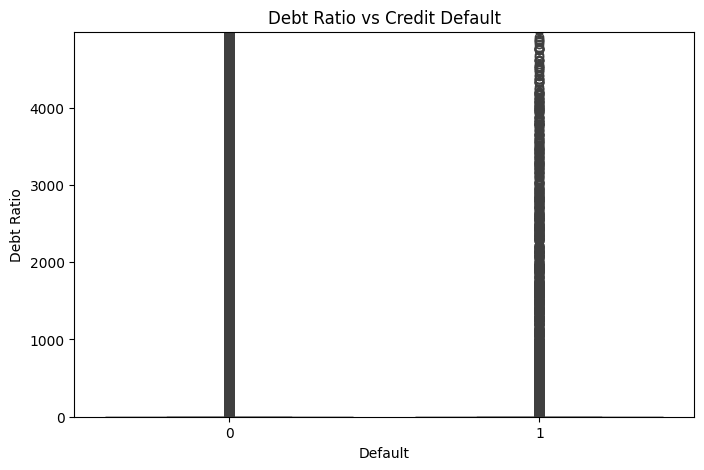

In [ ]:
# debt ratio vs default

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x='Default',
    y='Debt_Ratio'
)

plt.title(
    "Debt Ratio vs Credit Default"
)

plt.xlabel(
    "Default"
)

plt.ylabel(
    "Debt Ratio"
)

plt.ylim(
    0,
    df['Debt_Ratio'].quantile(0.99)
)

plt.show()

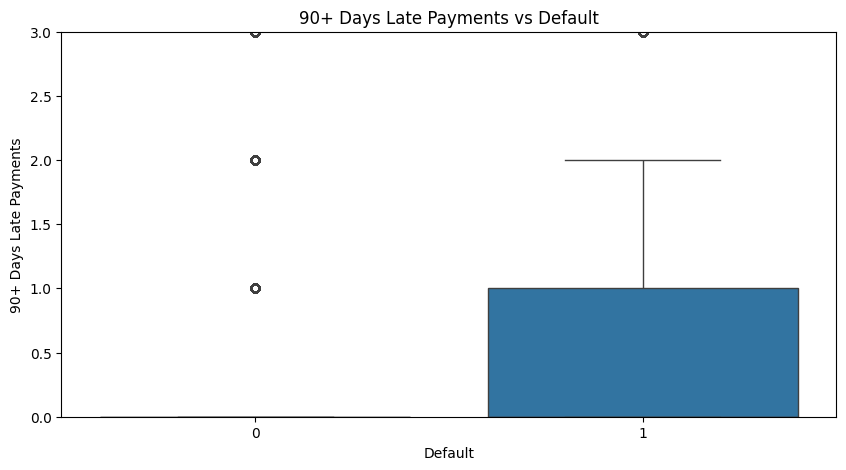

In [ ]:
# payment history vs default

plt.figure(figsize=(10,5))

sns.boxplot(
    data=df,
    x='Default',
    y='Late_90_Days'
)

plt.title(
    "90+ Days Late Payments vs Default"
)

plt.xlabel(
    "Default"
)

plt.ylabel(
    "90+ Days Late Payments"
)

plt.ylim(
    0,
    df['Late_90_Days'].quantile(0.99)
)

plt.show()


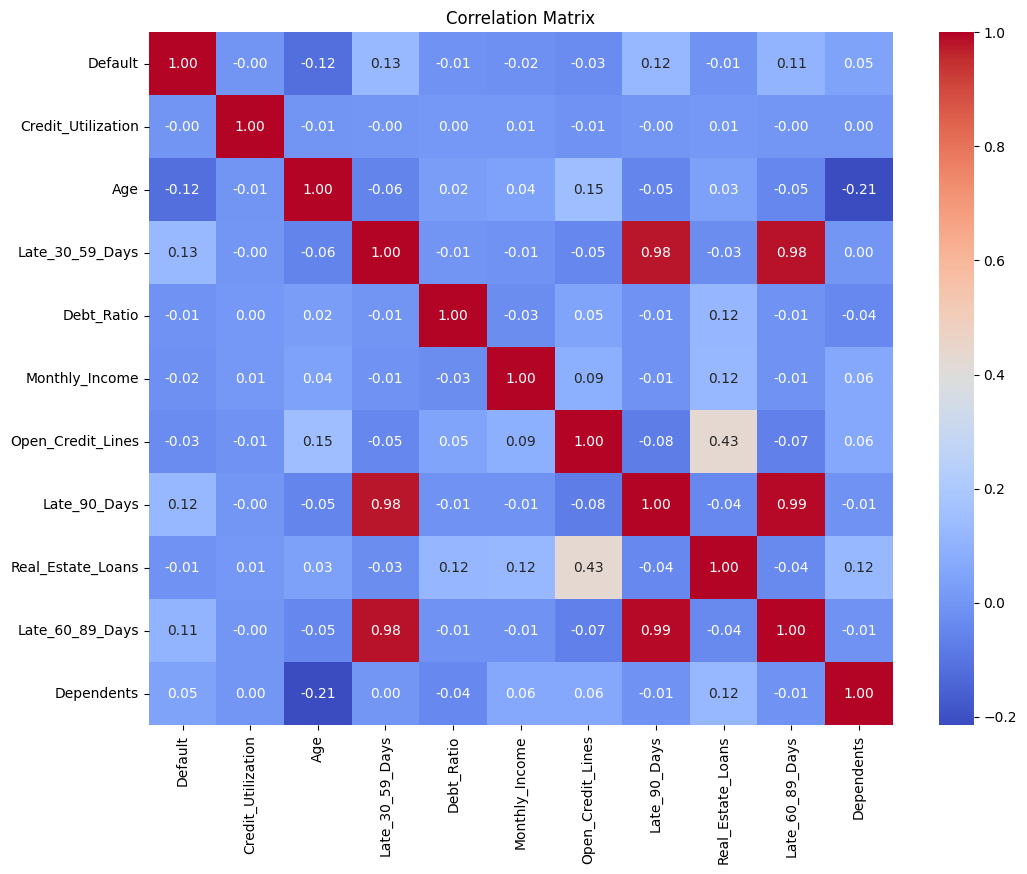

In [ ]:
# corelation matrix

plt.figure(figsize=(12,9))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title(
    "Correlation Matrix"
)

plt.show()

In [ ]:
# define x and y

X = df.drop(
    'Default',
    axis=1
)

y = df['Default']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (149391, 10)
y shape: (149391,)


In [ ]:
# features list

print("Features used by the model:")

for feature in X.columns:
    print("-", feature)

Features used by the model:
- Credit_Utilization
- Age
- Late_30_59_Days
- Debt_Ratio
- Monthly_Income
- Open_Credit_Lines
- Late_90_Days
- Real_Estate_Loans
- Late_60_89_Days
- Dependents


In [ ]:
# tarin-test-split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(
    "Training data:",
    X_train.shape
)

print(
    "Testing data:",
    X_test.shape
)

Training data: (119512, 10)
Testing data: (29879, 10)


In [ ]:
# handling missing values and scaling

numeric_features = X.columns.tolist()

preprocessor = Pipeline([
    (
        'imputer',
        SimpleImputer(
            strategy='median'
        )
    ),

    (
        'scaler',
        StandardScaler()
    )
])

**Logistic** **Regression**

In [ ]:
# Logistic Regression

logistic_model = Pipeline([
    (
        'preprocessor',
        preprocessor
    ),

    (
        'classifier',
        LogisticRegression(
            max_iter=1000,
            class_weight='balanced'
        )
    )
])

logistic_model.fit(
    X_train,
    y_train
)

# predict

lr_pred = logistic_model.predict(
    X_test
)

lr_prob = logistic_model.predict_proba(
    X_test
)[:,1]

In [ ]:
# Evaluate

print(
    classification_report(
        y_test,
        lr_pred
    )
)

lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

lr_precision = precision_score(
    y_test,
    lr_pred
)

lr_recall = recall_score(
    y_test,
    lr_pred
)

lr_f1 = f1_score(
    y_test,
    lr_pred
)

lr_auc = roc_auc_score(
    y_test,
    lr_prob
)

print("Logistic Regression")
print("-------------------------")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)
print("ROC-AUC  :", lr_auc)

              precision    recall  f1-score   support

           0       0.97      0.80      0.88     27877
           1       0.19      0.66      0.30      2002

    accuracy                           0.79     29879
   macro avg       0.58      0.73      0.59     29879
weighted avg       0.92      0.79      0.84     29879

Logistic Regression
-------------------------
Accuracy : 0.7949730580006025
Precision: 0.1945185185185185
Recall   : 0.6558441558441559
F1 Score : 0.3000457038391225
ROC-AUC  : 0.8036907311936906


**Decision** **Tree**

In [ ]:
# Decision Tree

decision_tree = Pipeline([
    (
        'preprocessor',
        preprocessor
    ),

    (
        'classifier',
        DecisionTreeClassifier(
            max_depth=6,
            random_state=42,
            class_weight='balanced'
        )
    )
])

decision_tree.fit(
    X_train,
    y_train
)

dt_pred = decision_tree.predict(
    X_test
)

dt_prob = decision_tree.predict_proba(
    X_test
)[:,1]

# Evaluate

print(
    classification_report(
        y_test,
        dt_pred
    )
)

              precision    recall  f1-score   support

           0       0.98      0.75      0.85     27877
           1       0.19      0.79      0.30      2002

    accuracy                           0.76     29879
   macro avg       0.58      0.77      0.58     29879
weighted avg       0.93      0.76      0.82     29879



**Random** **Forest**

In [ ]:
# Random Forest

random_forest = Pipeline([
    (
        'preprocessor',
        preprocessor
    ),

    (
        'classifier',
        RandomForestClassifier(
            n_estimators=200,
            max_depth=10,
            random_state=42,
            class_weight='balanced',
            n_jobs=-1
        )
    )
])

# Train

random_forest.fit(
    X_train,
    y_train
)

# predict

rf_pred = random_forest.predict(
    X_test
)

rf_prob = random_forest.predict_proba(
    X_test
)[:,1]

# evaluate

print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.98      0.82      0.89     27877
           1       0.23      0.74      0.35      2002

    accuracy                           0.82     29879
   macro avg       0.60      0.78      0.62     29879
weighted avg       0.93      0.82      0.86     29879



**Compare** **All** **3** **Models**

In [ ]:
# Compare all 3 models

results = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],

    'Precision': [
        precision_score(y_test, lr_pred),
        precision_score(y_test, dt_pred),
        precision_score(y_test, rf_pred)
    ],

    'Recall': [
        recall_score(y_test, lr_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],

    'F1 Score': [
        f1_score(y_test, lr_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ],

    'ROC-AUC': [
        roc_auc_score(y_test, lr_prob),
        roc_auc_score(y_test, dt_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

display(
    results.round(4)
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7950,0.1945,0.6558,0.3000,0.8037
1,Decision Tree,0.7569,0.1876,0.7892,0.3031,0.8403
2,Random Forest,0.8161,0.2297,0.7413,0.3507,0.8579


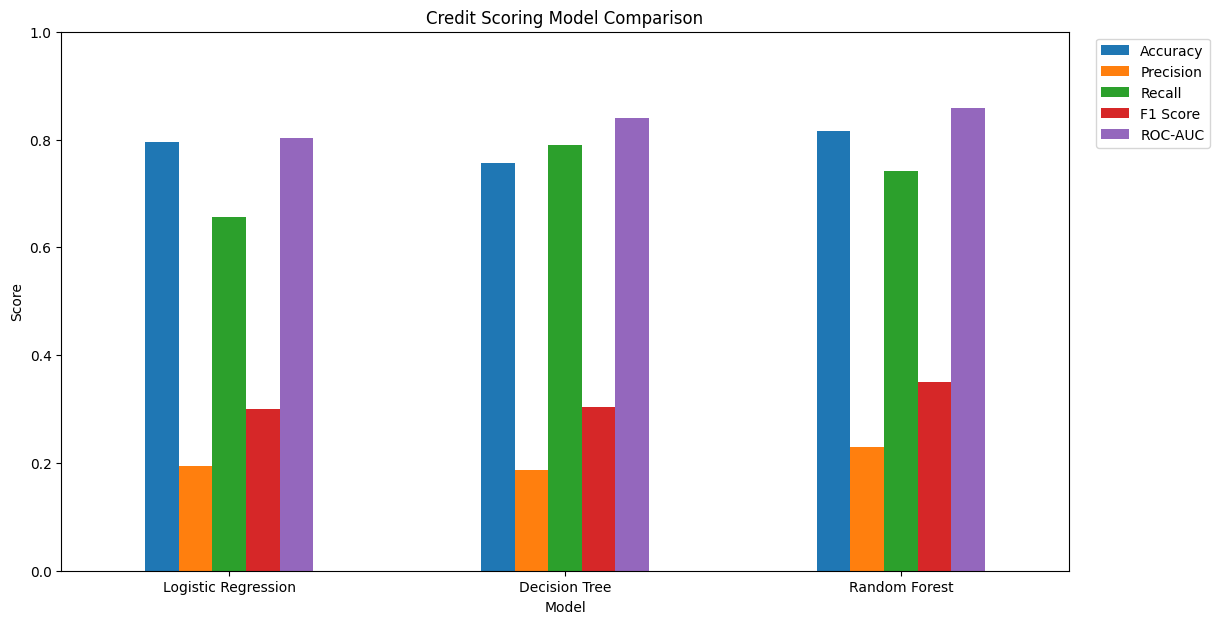

In [ ]:
# model comparison graph

results.set_index(
    'Model'
)[
    ['Accuracy',
     'Precision',
     'Recall',
     'F1 Score',
     'ROC-AUC']
].plot(
    kind='bar',
    figsize=(13,7)
)

plt.title(
    "Credit Scoring Model Comparison"
)

plt.ylabel(
    "Score"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=0
)

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc='upper left'
)

plt.show()

In [ ]:
# select best model

best_model_name = results.loc[
    results['F1 Score'].idxmax(),
    'Model'
]

print(
    "Best Model based on F1 Score:",
    best_model_name
)

Best Model based on F1 Score: Random Forest


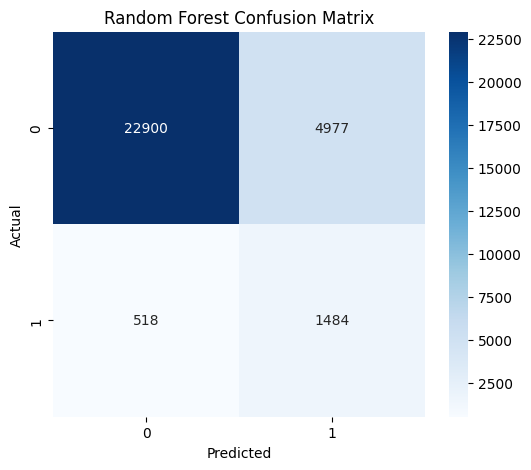

In [ ]:
# Confusion Matrix

cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title(
    "Random Forest Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.show()

<Figure size 900x700 with 0 Axes>

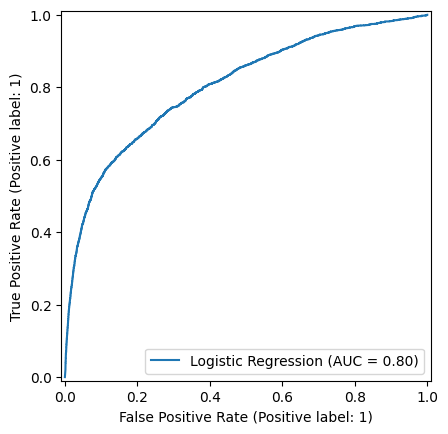

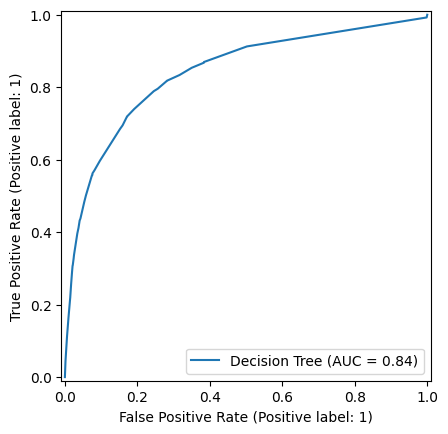

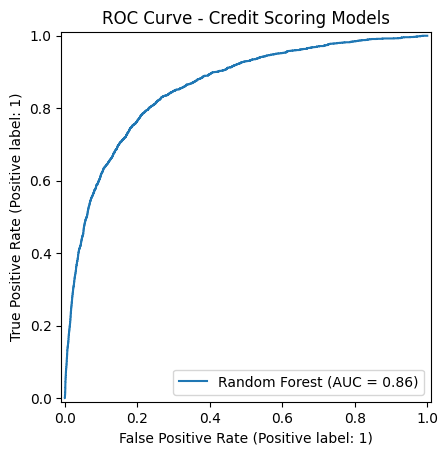

In [ ]:
# ROC Curve

plt.figure(figsize=(9,7))

RocCurveDisplay.from_predictions(
    y_test,
    lr_prob,
    name='Logistic Regression'
)

RocCurveDisplay.from_predictions(
    y_test,
    dt_prob,
    name='Decision Tree'
)

RocCurveDisplay.from_predictions(
    y_test,
    rf_prob,
    name='Random Forest'
)

plt.title(
    "ROC Curve - Credit Scoring Models"
)

plt.show()

In [ ]:
# Features Imp

rf_classifier = random_forest.named_steps[
    'classifier'
]

importance_df = pd.DataFrame({

    'Feature': X.columns,

    'Importance':
        rf_classifier.feature_importances_

})

importance_df = (
    importance_df
    .sort_values(
        'Importance',
        ascending=False
    )
)

display(
    importance_df
)

,Feature,Importance
0,Credit_Utilization,0.354489
6,Late_90_Days,0.189163
2,Late_30_59_Days,0.180501
8,Late_60_89_Days,0.095794
1,Age,0.056232
3,Debt_Ratio,0.038705
5,Open_Credit_Lines,0.030143
4,Monthly_Income,0.028611
7,Real_Estate_Loans,0.019357
9,Dependents,0.007008


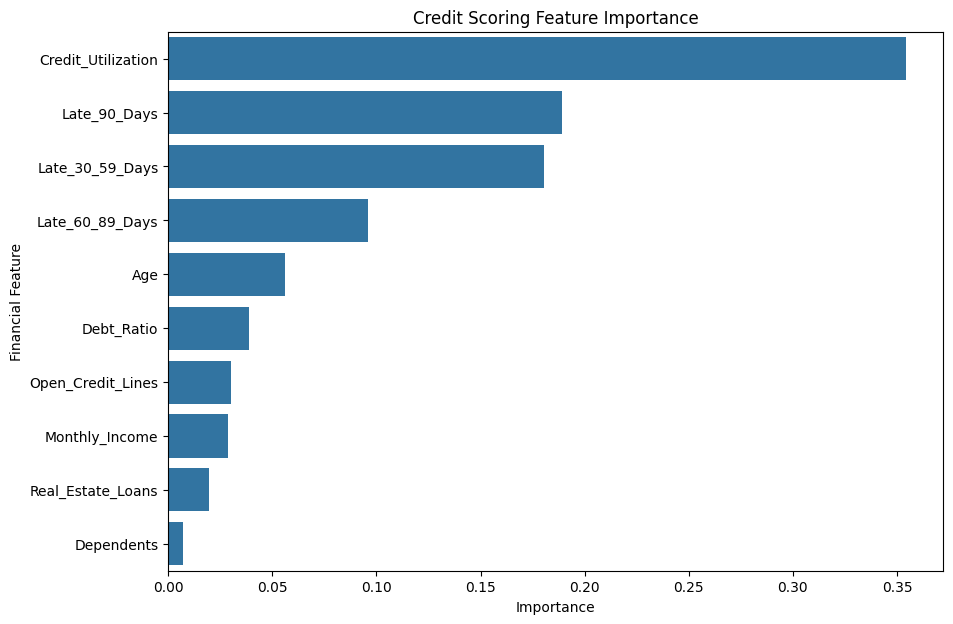

In [ ]:
# graph

plt.figure(figsize=(10,7))

sns.barplot(
    data=importance_df,
    x='Importance',
    y='Feature'
)

plt.title(
    "Credit Scoring Feature Importance"
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Financial Feature"
)

plt.show()

In [ ]:
# create a new Customer prediction

high_risk_customer = pd.DataFrame({

    'Credit_Utilization': [0.95],

    'Age': [28],

    'Late_30_59_Days': [3],

    'Debt_Ratio': [0.80],

    'Monthly_Income': [20000],

    'Open_Credit_Lines': [12],

    'Late_90_Days': [2],

    'Real_Estate_Loans': [3],

    'Late_60_89_Days': [2],

    'Dependents': [4]

})

In [ ]:
prediction = random_forest.predict(
    high_risk_customer
)[0]

probability = random_forest.predict_proba(
    high_risk_customer
)[0]

if prediction == 1:
    print("Prediction: HIGH CREDIT RISK")
else:
    print("Prediction: LOW CREDIT RISK")

print(
    "Default Probability:",
    round(probability[1] * 100, 2),
    "%"
)

Prediction: HIGH CREDIT RISK
Default Probability: 81.86 %


In [ ]:
# save the model

joblib.dump(
    random_forest,
    'credit_scoring_model.pkl'
)

print(
    "Credit scoring model saved successfully!"
)

Credit scoring model saved successfully!


**Steps Performed**

**Step 1: Dataset Collection**

We used a credit-related customer dataset containing financial and customer information such as:

Income
Debts
Payment history
Number of late payments
Dependents
Other credit-related attributes

The objective was to use these factors to predict the credit risk of a customer.

**Step 2: Data Understanding**

The dataset was first analyzed to understand:

Number of rows and columns
Data types
Missing values
Duplicate records
Distribution of the target variable
Important financial features

This helped us understand which information could be used by the machine-learning model.

**Step 3: Data Preprocessing**

The dataset was cleaned before training the model.

The preprocessing included:

Handling missing values
Removing unnecessary columns
Converting categorical information into numerical form where required
Checking duplicate records
Preparing the input features and target variable

Features such as income, debts, payment history, late-payment information, and dependents were considered as inputs where they were available in the dataset.

**Step 4: Feature Selection **

The important customer and financial features were selected for predicting credit risk.

The model learns the relationship between factors such as:

Income + Debt + Payment History + Late Payments + Other Customer Information → Credit Risk

The selected features must remain consistent between training and prediction.

**Step 5: Target Variable**

The target variable represents the customer's credit-risk category.

The model learns from historical customer records and their corresponding risk labels.

The problem was treated as a classification problem, where the model predicts the appropriate risk class.

**Step 6: Train-Test Split**

The prepared dataset was divided into:

80% Training Data
20% Testing Data

The training data was used to teach the model, while the testing data was used to check how well the model performs on unseen customers.

**Step 7: Random Forest Model**

A Random Forest Classifier was used to build the credit-risk prediction model.

Random Forest creates multiple decision trees and combines their predictions to produce the final classification.

The model can learn complex relationships between financial factors such as income, debt, payment history, and late payments.

**Step 8: Model Training**

The Random Forest model was trained using the selected financial features and the target risk labels.

During training, the model learns patterns such as how different combinations of:

High/low income
High/low debt
Good/poor payment history
Number of late payments
Dependents

are associated with different credit-risk categories.

**Step 9: Model Evaluation**

After training, the model was evaluated using the test dataset.

The following evaluation techniques were used:

Accuracy – percentage of correctly classified customers

Precision – correctness of the predicted risk class

Recall – ability to identify customers belonging to a particular risk class

F1-score – balance between precision and recall

Confusion Matrix – shows correct and incorrect predictions for each risk category

**Step 10: Credit Risk Prediction**

After training, the model can be used to predict the risk of a new customer.

The process is:

Customer Financial Information → Preprocessing → Random Forest Model → Risk Prediction

For example:

Customer Information
       ↓
Income
Debt
Payment History
Late Payments
Dependents
       ↓
Data Preprocessing
       ↓
Random Forest Model
       ↓
Credit Risk Prediction
       ↓
Low Risk / High Risk

The prediction must use exactly the same feature names and feature order that were used when training the Random Forest model.

**Step 11: Prediction Error Handling**

During the project, an error occurred because the prediction dataset contained features such as:

Dependents
Late_60_89_Days

that were not present when the Random Forest model was trained.

The solution is to make the prediction DataFrame match the model's training features exactly:

print(random_forest.feature_names_in_)

Then:

high_risk_customer = high_risk_customer[
    random_forest.feature_names_in_
]

After matching the features:

prediction = random_forest.predict(
    high_risk_customer
)[0]

This ensures that the model receives the same features it learned during training.

**Step 12: Final Prediction**

The trained model can then classify a new customer.

For example:

Income              → Customer financial information
Debt                → Customer financial information
Payment History     → Customer financial information
Late Payments       → Customer financial information
Dependents          → Customer financial information
                         ↓
                  Random Forest
                         ↓
                  Credit Risk
                         ↓
                High Risk / Low Risk

The actual prediction should be taken from the output of your trained model rather than manually assigning a result.

** Conclusion :**


We successfully developed a Credit Score/Credit Risk Prediction Model using machine learning. The project started with understanding and preprocessing customer financial data, including important factors such as income, debts, payment history, late payments, dependents, and other available credit-related information.

After cleaning and preparing the dataset, the relevant features were selected and divided into training and testing datasets. A Random Forest Classifier was then trained to learn the relationship between a customer's financial information and their credit-risk category.

The trained model was evaluated using accuracy, precision, recall, F1-score, and a confusion matrix to understand its performance. Finally, the model was used to predict the credit risk of new customers based on their financial information.

Overall, this task helped us understand how machine learning can be applied in the financial sector to analyze customer information and predict credit risk. The model can support financial institutions in making better-informed lending decisions by identifying customers who may have higher or lower credit risk based on their financial and payment-related characteristics.